In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.ndimage import uniform_filter


PROJECT = Path(r"Z:\Projects\monsoon-postprocessing")

PILOT_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "pilot_gefs_imerg_20180701_20180707.nc"
)

CORRECTED_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "pilot_bias_corrected_test_20180706_20180707.nc"
)

METRICS_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "pilot_bias_correction_metrics.csv"
)


with xr.open_dataset(PILOT_FILE) as ds:
    pilot_ds = ds.load()

print(pilot_ds)
print("Dates:", pilot_ds.date.values)

<xarray.Dataset> Size: 2MB
Dimensions:         (date: 7, latitude: 129, longitude: 121)
Coordinates:
  * date            (date) datetime64[ns] 56B 2018-07-01 ... 2018-07-07
  * latitude        (latitude) float64 1kB 6.0 6.25 6.5 6.75 ... 37.5 37.75 38.0
  * longitude       (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
Data variables:
    gefs_rainfall   (date, latitude, longitude) float32 437kB 1.91 1.21 ... 13.7
    imerg_rainfall  (date, latitude, longitude) float64 874kB nan nan ... nan
    forecast_error  (date, latitude, longitude) float64 874kB nan nan ... nan
Attributes:
    title:               Seven-day GEFS and IMERG pilot dataset
    period:              2018-07-01 to 2018-07-07
    forecast_source:     NOAA GEFSv12 reforecast c00
    observation_source:  NASA GPM IMERG Final V07
    forecast_lead:       24-48 hours
    error_definition:    GEFS minus IMERG
Dates: ['2018-07-01T00:00:00.000000000' '2018-07-02T00:00:00.000000000'
 '2018-07-03T00:00:00.000000000'

In [2]:
def continuous_metrics(forecast, observed):
    """Calculate continuous rainfall metrics."""

    forecast_values = np.asarray(forecast).ravel()
    observed_values = np.asarray(observed).ravel()

    valid = (
        np.isfinite(forecast_values)
        & np.isfinite(observed_values)
    )

    forecast_values = forecast_values[valid]
    observed_values = observed_values[valid]

    errors = forecast_values - observed_values

    rmse = np.sqrt(np.mean(errors ** 2))
    mae = np.mean(np.abs(errors))
    bias = np.mean(errors)

    if (
        np.std(forecast_values) > 0
        and np.std(observed_values) > 0
    ):
        correlation = np.corrcoef(
            forecast_values,
            observed_values
        )[0, 1]
    else:
        correlation = np.nan

    return {
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "Correlation": correlation
    }

In [3]:
def categorical_metrics(
    forecast,
    observed,
    threshold
):
    """Calculate event-based rainfall metrics."""

    forecast_values = np.asarray(forecast).ravel()
    observed_values = np.asarray(observed).ravel()

    valid = (
        np.isfinite(forecast_values)
        & np.isfinite(observed_values)
    )

    forecast_event = (
        forecast_values[valid] >= threshold
    )

    observed_event = (
        observed_values[valid] >= threshold
    )

    hits = np.sum(
        forecast_event & observed_event
    )

    misses = np.sum(
        ~forecast_event & observed_event
    )

    false_alarms = np.sum(
        forecast_event & ~observed_event
    )

    correct_negatives = np.sum(
        ~forecast_event & ~observed_event
    )

    total = (
        hits
        + misses
        + false_alarms
        + correct_negatives
    )

    csi_denominator = (
        hits + misses + false_alarms
    )

    pod_denominator = hits + misses
    far_denominator = hits + false_alarms

    csi = (
        hits / csi_denominator
        if csi_denominator > 0
        else np.nan
    )

    pod = (
        hits / pod_denominator
        if pod_denominator > 0
        else np.nan
    )

    far = (
        false_alarms / far_denominator
        if far_denominator > 0
        else np.nan
    )

    random_hits = (
        ((hits + misses) * (hits + false_alarms))
        / total
        if total > 0
        else np.nan
    )

    ets_denominator = (
        hits
        + misses
        + false_alarms
        - random_hits
    )

    ets = (
        (hits - random_hits) / ets_denominator
        if ets_denominator > 0
        else np.nan
    )

    return {
        "CSI": csi,
        "POD": pod,
        "FAR": far,
        "ETS": ets,
        "hits": int(hits),
        "misses": int(misses),
        "false_alarms": int(false_alarms)
    }

In [4]:
def calculate_fss(
    forecast,
    observed,
    threshold,
    neighborhood_size
):
    """Calculate FSS without smoothing across dates."""

    forecast_values = np.asarray(forecast)
    observed_values = np.asarray(observed)

    if forecast_values.ndim == 2:
        forecast_values = forecast_values[
            np.newaxis, :, :
        ]

        observed_values = observed_values[
            np.newaxis, :, :
        ]

    forecast_binary = (
        forecast_values >= threshold
    ).astype(float)

    observed_binary = (
        observed_values >= threshold
    ).astype(float)

    filter_size = (
        1,
        neighborhood_size,
        neighborhood_size
    )

    forecast_fraction = uniform_filter(
        forecast_binary,
        size=filter_size,
        mode="constant",
        cval=0
    )

    observed_fraction = uniform_filter(
        observed_binary,
        size=filter_size,
        mode="constant",
        cval=0
    )

    numerator = np.sum(
        (forecast_fraction - observed_fraction) ** 2
    )

    denominator = np.sum(
        forecast_fraction ** 2
        + observed_fraction ** 2
    )

    if denominator == 0:
        return np.nan

    return 1 - numerator / denominator

In [5]:
seven_day_metrics = continuous_metrics(
    pilot_ds["gefs_rainfall"],
    pilot_ds["imerg_rainfall"]
)

print("Seven-day raw GEFS verification")

for metric, value in seven_day_metrics.items():
    print(f"{metric}: {value:.3f}")

Seven-day raw GEFS verification
RMSE: 19.249
MAE: 10.557
Bias: 5.060
Correlation: 0.422


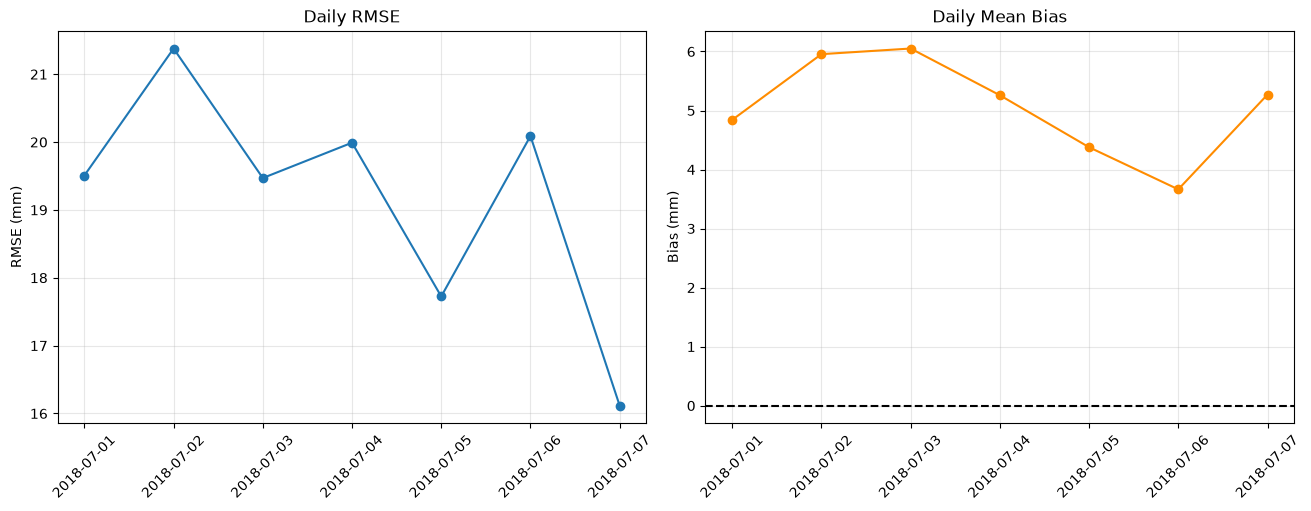

In [7]:
daily_rows = []

for date in pilot_ds.date.values:
    daily = pilot_ds.sel(date=date)

    result = continuous_metrics(
        daily["gefs_rainfall"],
        daily["imerg_rainfall"]
    )

    daily_rows.append({
        "date": pd.Timestamp(date).date(),
        **result
    })


daily_metrics_df = pd.DataFrame(
    daily_rows
)

daily_metrics_df

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    constrained_layout=True
)

axes[0].plot(
    daily_metrics_df["date"],
    daily_metrics_df["RMSE"],
    marker="o"
)

axes[0].set_title("Daily RMSE")
axes[0].set_ylabel("RMSE (mm)")
axes[0].tick_params(
    axis="x",
    rotation=45
)
axes[0].grid(alpha=0.3)


axes[1].plot(
    daily_metrics_df["date"],
    daily_metrics_df["Bias"],
    marker="o",
    color="darkorange"
)

axes[1].axhline(
    0,
    color="black",
    linestyle="--"
)

axes[1].set_title("Daily Mean Bias")
axes[1].set_ylabel("Bias (mm)")
axes[1].tick_params(
    axis="x",
    rotation=45
)
axes[1].grid(alpha=0.3)

plt.show()

In [8]:
train_ds = pilot_ds.isel(
    date=slice(0, 5)
)

test_ds = pilot_ds.isel(
    date=slice(5, 7)
)

print("Training dates:")
print(train_ds.date.values)

print("\nTesting dates:")
print(test_ds.date.values)

Training dates:
['2018-07-01T00:00:00.000000000' '2018-07-02T00:00:00.000000000'
 '2018-07-03T00:00:00.000000000' '2018-07-04T00:00:00.000000000'
 '2018-07-05T00:00:00.000000000']

Testing dates:
['2018-07-06T00:00:00.000000000' '2018-07-07T00:00:00.000000000']


In [9]:
training_error = (
    train_ds["gefs_rainfall"]
    - train_ds["imerg_rainfall"]
)

training_bias = float(
    training_error.mean(
        skipna=True
    )
)

print(
    "Training mean bias:",
    training_bias,
    "mm"
)

Training mean bias: 5.296760967312327 mm


In [10]:
raw_test = test_ds["gefs_rainfall"]
observed_test = test_ds["imerg_rainfall"]

corrected_test = (
    raw_test - training_bias
).clip(min=0)

corrected_test.name = "corrected_rainfall"

corrected_test.attrs = {
    "long_name": "Additive bias-corrected GEFS rainfall",
    "units": "mm",
    "correction": (
        f"raw forecast minus {training_bias:.4f} mm"
    ),
    "training_period": (
        "2018-07-01 to 2018-07-05"
    )
}

print(corrected_test)

<xarray.DataArray 'corrected_rainfall' (date: 2, latitude: 129, longitude: 121)> Size: 125kB
array([[[135.42323   , 111.473236  ,  72.85324   , ...,   0.        ,
           0.        ,   0.        ],
        [137.90321   ,  94.84324   ,  54.77324   , ...,   0.        ,
           0.        ,   0.        ],
        [113.85323   ,  84.95324   ,  53.663235  , ...,   0.        ,
           0.        ,   0.        ],
        ...,
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.38323927]],

       [[  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.2

In [11]:
raw_metrics = continuous_metrics(
    raw_test,
    observed_test
)

corrected_metrics = continuous_metrics(
    corrected_test,
    observed_test
)


comparison_rows = []

for metric in [
    "RMSE",
    "MAE",
    "Bias",
    "Correlation"
]:
    raw_value = raw_metrics[metric]
    corrected_value = corrected_metrics[metric]

    comparison_rows.append({
        "metric": metric,
        "raw": raw_value,
        "corrected": corrected_value,
        "change": corrected_value - raw_value
    })


continuous_comparison_df = pd.DataFrame(
    comparison_rows
)

continuous_comparison_df

,metric,raw,corrected,change
0,RMSE,18.210973,17.224459,-0.986515
1,MAE,9.876634,8.268497,-1.608137
2,Bias,4.467036,1.238070,-3.228966
3,Correlation,0.416030,0.405718,-0.010312


In [12]:
thresholds = [
    64.5,
    115.6
]

categorical_rows = []


for threshold in thresholds:
    raw_result = categorical_metrics(
        raw_test,
        observed_test,
        threshold
    )

    corrected_result = categorical_metrics(
        corrected_test,
        observed_test,
        threshold
    )

    for model_name, result in [
        ("Raw GEFS", raw_result),
        ("Bias corrected", corrected_result)
    ]:
        categorical_rows.append({
            "model": model_name,
            "threshold_mm": threshold,
            **result
        })


categorical_comparison_df = pd.DataFrame(
    categorical_rows
)

categorical_comparison_df

,model,threshold_mm,CSI,POD,FAR,ETS,hits,misses,false_alarms
0,Raw GEFS,64.5,0.069556,0.125227,0.864706,0.060754,69,482,441
1,Bias corrected,64.5,0.063232,0.098004,0.848739,0.056038,54,497,303
2,Raw GEFS,115.6,0.000000,0.000000,1.000000,-0.000522,0,128,18
3,Bias corrected,115.6,0.000000,0.000000,1.000000,-0.000307,0,128,10


In [13]:
neighborhood_sizes = [
    1,
    3,
    5,
    9
]

fss_rows = []


for threshold in thresholds:
    for size in neighborhood_sizes:
        raw_fss = calculate_fss(
            raw_test,
            observed_test,
            threshold,
            size
        )

        corrected_fss = calculate_fss(
            corrected_test,
            observed_test,
            threshold,
            size
        )

        fss_rows.append({
            "model": "Raw GEFS",
            "threshold_mm": threshold,
            "neighborhood_cells": size,
            "approximate_scale_km": size * 25,
            "FSS": raw_fss
        })

        fss_rows.append({
            "model": "Bias corrected",
            "threshold_mm": threshold,
            "neighborhood_cells": size,
            "approximate_scale_km": size * 25,
            "FSS": corrected_fss
        })


fss_comparison_df = pd.DataFrame(
    fss_rows
)

fss_comparison_df

,model,threshold_mm,neighborhood_cells,approximate_scale_km,FSS
0,Raw GEFS,64.5,1,25,0.127072
1,Bias corrected,64.5,1,25,0.116004
2,Raw GEFS,64.5,3,75,0.201661
3,Bias corrected,64.5,3,75,0.192379
4,Raw GEFS,64.5,5,125,0.256428
5,Bias corrected,64.5,5,125,0.244927
6,Raw GEFS,64.5,9,225,0.335401
7,Bias corrected,64.5,9,225,0.318033
8,Raw GEFS,115.6,1,25,0.000000
9,Bias corrected,115.6,1,25,0.000000


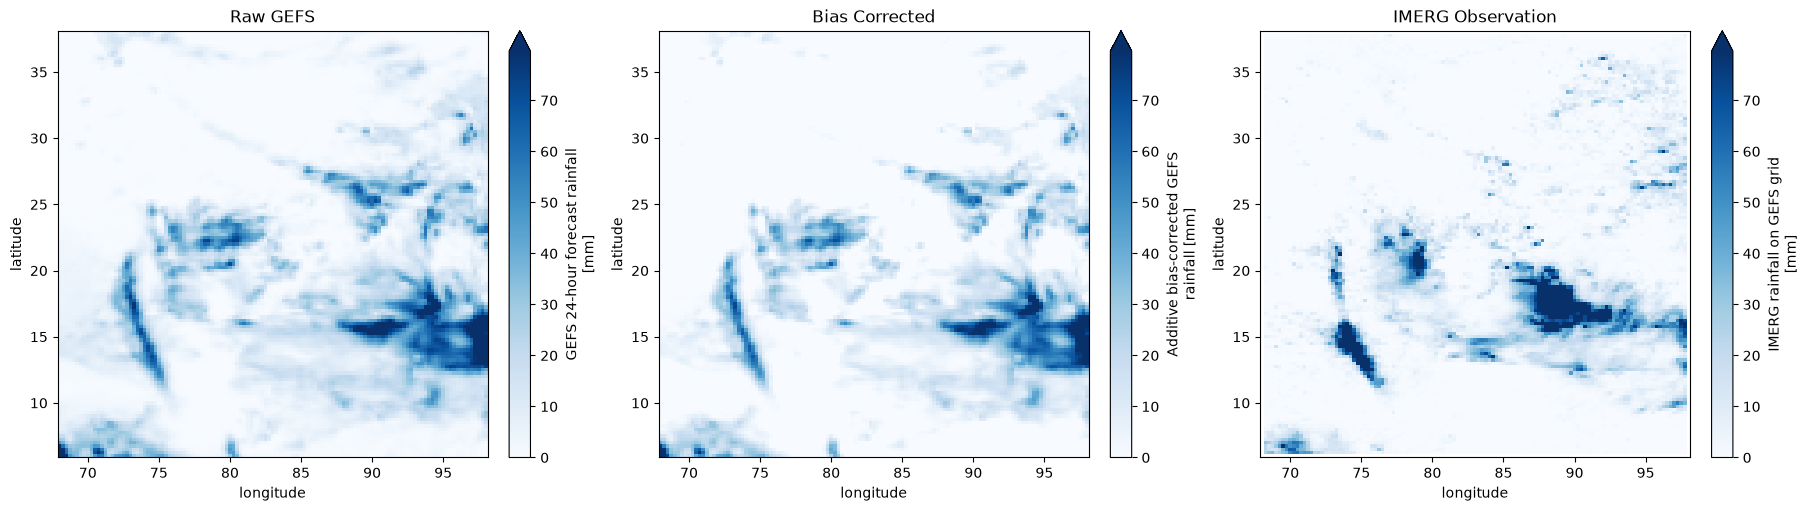

In [14]:
plot_date = "2018-07-06"

raw_day = raw_test.sel(date=plot_date)
observed_day = observed_test.sel(date=plot_date)
corrected_day = corrected_test.sel(date=plot_date)

comparison_max = float(
    np.nanpercentile(
        np.concatenate([
            raw_day.values.ravel(),
            observed_day.values.ravel(),
            corrected_day.values.ravel()
        ]),
        99
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True
)

raw_day.plot(
    ax=axes[0],
    cmap="Blues",
    vmin=0,
    vmax=comparison_max
)
axes[0].set_title("Raw GEFS")

corrected_day.plot(
    ax=axes[1],
    cmap="Blues",
    vmin=0,
    vmax=comparison_max
)
axes[1].set_title("Bias Corrected")

observed_day.plot(
    ax=axes[2],
    cmap="Blues",
    vmin=0,
    vmax=comparison_max
)
axes[2].set_title("IMERG Observation")

plt.show()

In [15]:
corrected_ds = xr.Dataset({
    "raw_gefs_rainfall": raw_test,
    "corrected_rainfall": corrected_test,
    "imerg_rainfall": observed_test,
    "raw_error": raw_test - observed_test,
    "corrected_error": (
        corrected_test - observed_test
    )
})

corrected_ds.attrs = {
    "title": "Pilot additive bias correction",
    "training_period": "2018-07-01 to 2018-07-05",
    "testing_period": "2018-07-06 to 2018-07-07",
    "training_bias_mm": training_bias,
    "correction_method": "global additive mean bias"
}

corrected_ds.to_netcdf(
    CORRECTED_FILE,
    mode="w",
    engine="netcdf4"
)

print("Saved:", CORRECTED_FILE.exists())
print("Location:", CORRECTED_FILE)

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\pilot_bias_corrected_test_20180706_20180707.nc


In [16]:
metric_rows = []


for model_name, results in [
    ("Raw GEFS", raw_metrics),
    ("Bias corrected", corrected_metrics)
]:
    for metric, value in results.items():
        metric_rows.append({
            "model": model_name,
            "metric": metric,
            "threshold_mm": np.nan,
            "neighborhood_cells": np.nan,
            "value": value
        })


for row in categorical_rows:
    for metric in [
        "CSI",
        "POD",
        "FAR",
        "ETS"
    ]:
        metric_rows.append({
            "model": row["model"],
            "metric": metric,
            "threshold_mm": row["threshold_mm"],
            "neighborhood_cells": np.nan,
            "value": row[metric]
        })


for row in fss_rows:
    metric_rows.append({
        "model": row["model"],
        "metric": "FSS",
        "threshold_mm": row["threshold_mm"],
        "neighborhood_cells": row[
            "neighborhood_cells"
        ],
        "value": row["FSS"]
    })


metrics_df = pd.DataFrame(metric_rows)

metrics_df.to_csv(
    METRICS_FILE,
    index=False
)

print("Saved:", METRICS_FILE.exists())
print("Location:", METRICS_FILE)

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\pilot_bias_correction_metrics.csv


In [17]:
print("Training bias:", training_bias)
display(continuous_comparison_df)
display(categorical_comparison_df)

Training bias: 5.296760967312327


,metric,raw,corrected,change
0,RMSE,18.210973,17.224459,-0.986515
1,MAE,9.876634,8.268497,-1.608137
2,Bias,4.467036,1.238070,-3.228966
3,Correlation,0.416030,0.405718,-0.010312


,model,threshold_mm,CSI,POD,FAR,ETS,hits,misses,false_alarms
0,Raw GEFS,64.5,0.069556,0.125227,0.864706,0.060754,69,482,441
1,Bias corrected,64.5,0.063232,0.098004,0.848739,0.056038,54,497,303
2,Raw GEFS,115.6,0.000000,0.000000,1.000000,-0.000522,0,128,18
3,Bias corrected,115.6,0.000000,0.000000,1.000000,-0.000307,0,128,10
